 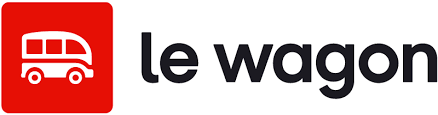

# Predicting airline satisfaction!


In this exercise we are going to try another classification task and predict the satisfaction of an airline customer with their flight!

Run the cell below to load the data

In [1]:
import pandas as pd

url = "https://wagon-public-datasets.s3.amazonaws.com/data-analytics/machine-learning/airline_satisfaction.csv"

airline_df = pd.read_csv(url)

airline_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Start by investigating the dataset

- How many columns / rows do we have?
- What are our targets / features?
- What kind of data are our features?
- Look at the target, what classification task are we going to be doing?
- Do we have any missing data?

In [27]:
print(f'Number of Columns: {len(airline_df.columns)}')
print(f'Number of rows: {len(airline_df)}')
print('Target: Satisfaction')
print(airline_df.dtypes)
print(airline_df.isnull().sum())

Number of Columns: 24
Number of rows: 103904
Target: Satisfaction
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                       

Our target and some of our features are not yet ready to be used in a model.

Start by removing any columns that you think are unnecessary:

<details>
    <summary><i>Answer:</i></summary>
     
The 'Unnamed: 0' column is a hangover from excel, we can remove this.

Also, the 'id' column will not provide any info that is relevant to our model so this can be removed.
</details>       

In [8]:
airline_df.drop(columns='Unnamed: 0', inplace= True)

We have *missing data* in one of our columns! Fill in the missing values with the median value of the column

<details>
    <summary><i>Hint:</i></summary>
     
Remember to use the `.fillna()` method of your dataframe.

You can use `.median()` method of a pandas series to get the median value
</details>    

In [11]:
airline_df['Arrival Delay in Minutes'].fillna(airline_df['Arrival Delay in Minutes'].median(), inplace=True)

/tmp/ipykernel_48110/3369106542.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airline_df['Arrival Delay in Minutes'].fillna(airline_df['Arrival Delay in Minutes'].median(), inplace=True)


Now we need to get our **target** ready!

Encode the target variable below and save it as 'airline_target'

In [13]:
airline_target = airline_df['satisfaction']

We have to split our dataset now. Choose a split of 80/20.

In [ ]:
from sklearn.model_selection import train_test_split

X = airline_df.drop(columns='satisfaction')

X_train, X_test, y_train, y_test = train_test_split(X, airline_target, train_size=0.8, random_state=0)

Next step is to preprocess our data.
Let's deal with the categorical features in our dataset first.

A number of these contain string labels that must be transformed into numeric values so that they can be understood by the model that we end up training.

Encode the following columns `['Gender', 'Customer Type', 'Type of Travel', 'Class']` as a dataframe called 'cat_features'. Consider trying to use sklearn's `OneHotEncoder` to do this!


<details>
    <summary><i>Hint 1:</i></summary>

Be sure to check how many labels each column has. If any columns are binary, you can use the parameter `drop='if_binary'` in your One Hot Encoder to preserve only one column if there are two labels.

Remember, if there are only two labels, the two columns produced by the encoder will be the inverse of each other and hence contain the same information!
</details>  

<details>
    <summary><i>Hint 2:</i></summary>

If the output of your One Hot Encoder doesn't look right, check the 'sparse_output' parameter of your encoder.
</details>  


<details>
    <summary><i>Hint 3:</i></summary>

You can extract the names for your columns with the `.get_feature_names_out()` method of your One Hot Encoder.
</details>

In [23]:
from sklearn.preprocessing import OneHotEncoder

coder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

X_train_cat = X_train.select_dtypes(exclude=['number'])
X_test_cat = X_test.select_dtypes(exclude=['number'])

X_train_cat = coder.fit_transform(X_train_cat)
X_test_cat = coder.transform(X_test_cat)

Next we will address the numeric features in our dataset.

Create dataframes that contains the normalized numeric features.

<details>
    <summary><i>Hint 1:</i></summary>

Remember that you can use `.select_dtypes()` to select only columns of a specific data type from a dataframe!
</details>  


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')

X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)

Now that we have processed our numeric and cateogrical features, let's combine them back into one variable called 'X_train_preprocessed' and 'X_test_preprocessed' that contains **all** of our **preprocessed features** for each train and test data.

<details>
    <summary><i>Hint 1:</i></summary>

`pd.concat()` (The 'axis' parameter is important!)
</details>  

In [29]:
prep_feat_train = pd.concat([X_train_num, X_train_cat], axis=1)
prep_feat_test = pd.concat([X_test_num, X_test_cat], axis=1)

Well done! That's our preprocessing done. It's not a super quick processes, but it is **very** important.

Now, let's create our models.

We will start with a simple classifier. Train a logistic regression model on your train data. Then evaluate it's accuracy score on your test data!

In [30]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(prep_feat_train, y_train)
score = log_reg.score(prep_feat_test, y_test)
print(score)

0.8776767239305134


88% accuracy isn't bad, but maybe we can do better...

Let's try using a more complex model on our preprocessed data. A [random forest classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) might be a good alternative choice.

<details>
<summary><i>Note</i></summary>

Random Forest models reduce overfitting by averaging multiple decision trees and is less sensitive to noise and outliers in the data.
</details>

Try instantiating and fitting a random forest classifier model with the same data as above and compare the accuracy scores.

In [31]:
# your code here
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(prep_feat_train, y_train)
score = rfc.score(prep_feat_test, y_test)
print(score)

0.9644867908185362


Your random forest classifier should have an **accuracy score of around 0.96**, which is a substantial improvement on the simple model we ran earlier!

Certain models will peform better than other dependent on your data. Knowing which one to use intuitively is a matter of practice. For example, random forest models are good for data that is *non-linear* in nature.

[Here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) is a list of classifiers available on sklearn. The explanatory documentation is a fanstastic resource.

*In the cell below pick one of the models in the documentation and use it to predict airline customer satisfaction!*

Finally, remember that **preprocessing is integral to the analysis pipeline**. A model will only return quality output **if the input is also quality**, so expect to always spend a decent amount of time on cleaning / encoding / feature engineering!